In [172]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Parkinsons Disease

In [173]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [174]:
# Load Parkinson Disease Dataset
df_p = pd.read_csv("/content/drive/MyDrive/Guvi/Project/multiple_disease_prediction/parkinsons.csv")

In [175]:
df_p.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


**Column details from Kaggle**

Link: [Parkinson's Disease Dataset](https://www.kaggle.com/datasets/vikasukani/parkinsons-disease-data-set/data)

**name** - ASCII subject name and recording number

**MDVP:Fo(Hz)** - Average vocal fundamental frequency

**MDVP:Fhi(Hz)** - Maximum vocal fundamental frequency

**MDVP:Flo(Hz)** - Minimum vocal fundamental frequency

**MDVP:Jitter(%) , MDVP:Jitter(Abs) , MDVP:RAP , MDVP:PPQ , Jitter:DDP** - Several measures of variation in fundamental frequency

**MDVP:Shimmer , MDVP:Shimmer(dB) , Shimmer:APQ3 , Shimmer:APQ5 , MDVP:APQ , Shimmer:DDA** - Several measures of variation in amplitude

**NHR , HNR** - Two measures of ratio of noise to tonal components in the voice

**status** - Health status of the subject (one) - Parkinson's, (zero) - healthy

**RPDE , D2** - Two nonlinear dynamical complexity measures

**DFA**- Signal fractal scaling exponent

**spread1 , spread2 , PPE** - Three nonlinear measures of fundamental frequency variation

In [176]:
df_p.shape

(195, 24)

In [177]:
df_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [178]:
df_p.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [179]:
df_p.isnull().sum().sum()

np.int64(0)

In [180]:
# status - shows having Disease or Not (target)
df_p["status"].unique()

array([1, 0])

- 1 - Parkinson's Disease
- 0 - No Parkinson's Disease

In [181]:
df_p["status"].value_counts()

,count
status,
1,147
0,48


In [182]:
df_p["status"].value_counts(normalize=True)*100

,proportion
status,
1,75.384615
0,24.615385


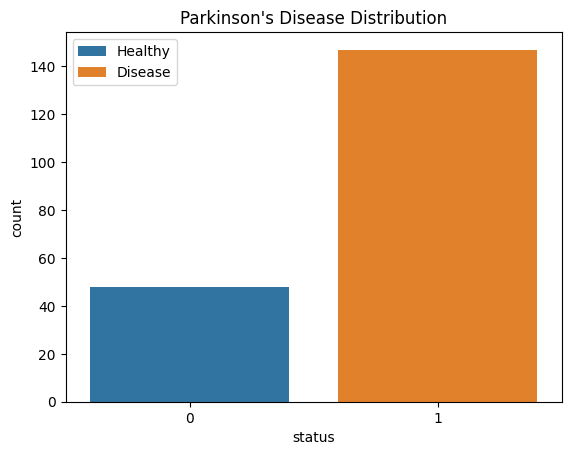

In [183]:
# Visualise status (target)
sns.countplot(data=df_p, x="status", hue="status", legend=True)
plt.title("Parkinson's Disease Distribution")
plt.legend(["Healthy", "Disease"], loc="upper left")
plt.show()

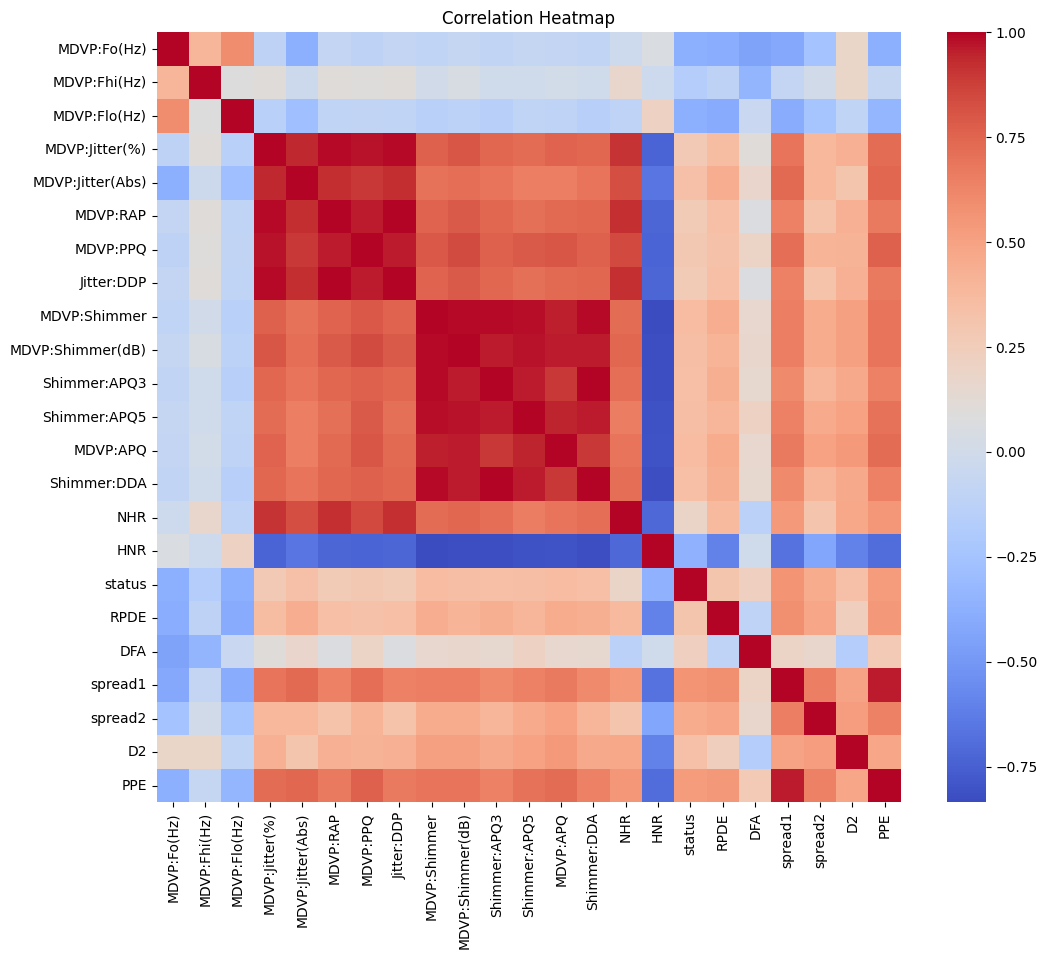

In [184]:
# Correlation
without_name = df_p.drop(columns=["name"])
plt.figure(figsize=(12, 10))
sns.heatmap(without_name.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [185]:
# Feature and Target
df_p.columns

Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE'],
      dtype='object')

In [186]:
# Dropping name and status(target)
X_p = df_p.drop(columns=["name", "status"], axis=1)
y_p = df_p["status"]

In [187]:
# Train Test Split
from sklearn.model_selection import train_test_split

In [188]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_p, y_p, test_size=0.2, random_state=42, stratify=y_p)

In [189]:
X_train_p.shape

(156, 22)

In [190]:
X_test_p.shape

(39, 22)

In [191]:
y_train_p.shape

(156,)

In [192]:
y_test_p.shape

(39,)

In [193]:
# Scaling using StandardScaler
from sklearn.preprocessing import StandardScaler

In [194]:
scaler_p = StandardScaler()
X_train_scaled_p = scaler_p.fit_transform(X_train_p)
X_test_scaled_p = scaler_p.transform(X_test_p)

In [195]:
# Model Training
# Logistic Regression
from sklearn.linear_model import LogisticRegression

lr_p = LogisticRegression(max_iter=1000, random_state=42)
lr_p.fit(X_train_scaled_p, y_train_p)
lr_pred_p = lr_p.predict(X_test_scaled_p)

In [196]:
lr_pred_p.shape

(39,)

In [197]:
# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [198]:
# Evaluation Function
def evaluate(model_name, y_test_p, lr_pred_p):
  print(f"{model_name} Evaluation:")
  print(f"Accuracy Score: {accuracy_score(y_test_p, lr_pred_p)*100:.2f}%")
  print(f"Precision Score: {precision_score(y_test_p, lr_pred_p)*100:.2f}%")
  print(f"Recall Score: {recall_score(y_test_p, lr_pred_p)*100:.2f}%")
  print(f"F1 Score: {f1_score(y_test_p, lr_pred_p)*100:.2f}%")

In [199]:
evaluate("Logistic Regression", y_test_p, lr_pred_p)

Logistic Regression Evaluation:
Accuracy Score: 92.31%
Precision Score: 93.33%
Recall Score: 96.55%
F1 Score: 94.92%


In [200]:
# Random forest
from sklearn.ensemble import RandomForestClassifier

rf_p = RandomForestClassifier(random_state=42)
rf_p.fit(X_train_scaled_p, y_train_p)
rf_pred_p = rf_p.predict(X_test_scaled_p)

In [201]:
rf_pred_p.shape

(39,)

In [202]:
# Evaluate Random forest
evaluate("Random Forest", y_test_p, rf_pred_p)

Random Forest Evaluation:
Accuracy Score: 92.31%
Precision Score: 93.33%
Recall Score: 96.55%
F1 Score: 94.92%


In [203]:
# XGBoost Model
from xgboost import XGBClassifier

xg_p = XGBClassifier(eval_metric="logloss", random_state=42)
xg_p.fit(X_train_scaled_p, y_train_p)
xg_pred_p = xg_p.predict(X_test_scaled_p)

In [204]:
xg_pred_p.shape

(39,)

In [205]:
# Evaluate XGBoost
evaluate("XGBoost Classifier", y_test_p, xg_pred_p)

XGBoost Classifier Evaluation:
Accuracy Score: 92.31%
Precision Score: 93.33%
Recall Score: 96.55%
F1 Score: 94.92%


In [206]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

# Logistic Regression
print("Logistic Regression: \n", confusion_matrix(y_test_p, lr_pred_p))
# Random Forest
print("Random Forest: \n", confusion_matrix(y_test_p, rf_pred_p))
# XGBoost
print("XGBoost: \n", confusion_matrix(y_test_p, xg_pred_p))

Logistic Regression: 
 [[ 8  2]
 [ 1 28]]
Random Forest: 
 [[ 8  2]
 [ 1 28]]
XGBoost: 
 [[ 8  2]
 [ 1 28]]


In [207]:
# Evaluate modesl with cross_val_score
from sklearn.model_selection import cross_val_score

# Logistic Regression
lr_score_p = cross_val_score(lr_p, X_p, y_p, cv=5, scoring="f1")
print("Logistic Regression")
print("F1 Mean: ", lr_score_p.mean())
print("Standard Deviation: ", lr_score_p.std())

Logistic Regression
F1 Mean:  0.8922386921169883
Standard Deviation:  0.039668049153538255


In [208]:
# Random Forest
rf_score_p = cross_val_score(rf_p, X_p, y_p, cv=5, scoring="f1")
print("Random Forest")
print("F1 Mean: ", rf_score_p.mean())
print("Standard Deviation: ", rf_score_p.std())

Random Forest
F1 Mean:  0.8663709431522972
Standard Deviation:  0.013885227161539284


In [209]:
# XGBoost
xg_score_p = cross_val_score(xg_p, X_p, y_p, cv=5, scoring="f1")
print("Logistic Regression")
print("F1 Mean: ", xg_score_p.mean())
print("Standard Deviation: ", xg_score_p.std())

Logistic Regression
F1 Mean:  0.9006398897712458
Standard Deviation:  0.04653229995296953


## Liver Dataset

In [210]:
# Load liver dataset
df_l = pd.read_csv("/content/drive/MyDrive/Guvi/Project/multiple_disease_prediction/indian_liver_patient.csv")

In [211]:
df_l.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


Model Details Link: [Indian Liver Patient Dataset](https://archive.ics.uci.edu/dataset/225/ilpd+indian+liver+patient+dataset)

Kaggle Details: [Indian Liver Patient Dataset](https://www.kaggle.com/datasets/uciml/indian-liver-patient-records)

**Columns:**

1. Age of the patient
2. Gender of the patient
3. Total Bilirubin
4. Direct Bilirubin
5. Alkaline Phosphotase
6. Alamine Aminotransferase
7. Aspartate Aminotransferase
8. Total Protiens
9. Albumin
10. Albumin and Globulin Ratio
11. Dataset: field used to split the data into two sets (patient with liver disease, or no disease)

In [212]:
df_l.shape

(583, 11)

In [213]:
df_l["Dataset"].unique()

array([1, 2])

In [214]:
df_l["Dataset"].value_counts()

,count
Dataset,
1,416
2,167


In [215]:
# mapping "Dataset" 1(liver disease) as 1 and 2(no disease) as 0
df_l["Dataset"] = df_l["Dataset"].map({
    1: 1,
    2: 0
})

In [216]:
df_l["Dataset"].unique()

array([1, 0])

In [217]:
df_l["Dataset"].value_counts()

,count
Dataset,
1,416
0,167


In [218]:
df_l.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [219]:
df_l.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,4


In [220]:
df_l["Albumin_and_Globulin_Ratio"].unique()

array([0.9 , 0.74, 0.89, 1.  , 0.4 , 1.3 , 1.1 , 1.2 , 0.8 , 0.6 , 0.87,
       0.7 , 0.92, 0.55, 0.5 , 1.85, 0.95, 1.4 , 1.18, 0.61, 1.34, 1.39,
       1.6 , 1.58, 1.25, 0.78, 0.76, 1.55, 0.71, 0.62, 0.67, 0.75, 1.16,
       1.5 , 1.66, 0.96, 1.38, 0.52, 0.47, 0.93, 0.48, 0.58, 0.69, 1.27,
       1.12, 1.06, 0.53, 1.03, 0.68,  nan, 1.9 , 1.7 , 1.8 , 0.3 , 0.97,
       0.35, 1.51, 0.64, 0.45, 1.36, 0.88, 1.09, 1.11, 1.72, 2.8 , 0.46,
       0.39, 1.02, 2.5 , 0.37])

In [221]:
df_l["Albumin_and_Globulin_Ratio"].isnull().sum()

np.int64(4)

In [222]:
df_l["Albumin_and_Globulin_Ratio"].mean()

np.float64(0.9470639032815197)

In [223]:
df_l["Albumin_and_Globulin_Ratio"].median()

0.93

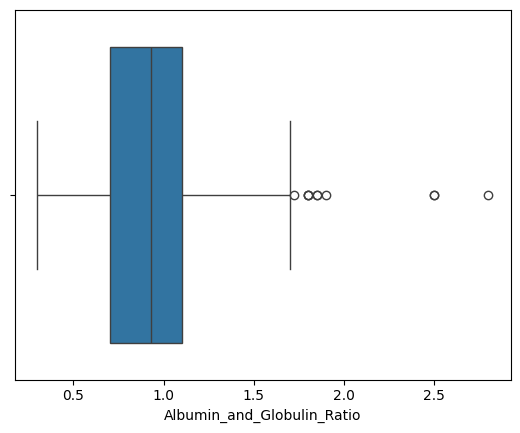

In [224]:
# Visualize Albumin_and_Globulin_Ratio
sns.boxplot(x=df_l['Albumin_and_Globulin_Ratio'])
plt.show()

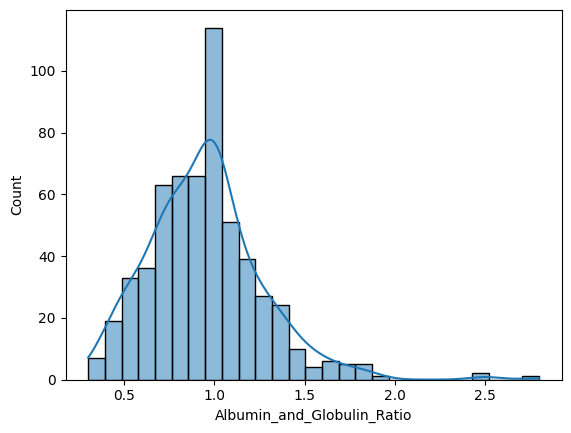

In [225]:
sns.histplot(df_l["Albumin_and_Globulin_Ratio"], kde=True)
plt.show()

In [226]:
df_l["Albumin_and_Globulin_Ratio"].skew()

np.float64(0.9922994479668144)

In [227]:
# Filling null values with median
df_l["Albumin_and_Globulin_Ratio"] = df_l["Albumin_and_Globulin_Ratio"].fillna(df_l["Albumin_and_Globulin_Ratio"].median())

In [228]:
df_l["Albumin_and_Globulin_Ratio"].isnull().sum()

np.int64(0)

In [229]:
df_l.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  583 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [230]:
df_l.select_dtypes(include=["object"]).value_counts()

,count
Gender,
Male,441
Female,142


In [231]:
# Encode Gender column, Male - 1 and Female - 0
df_l["Gender"] = df_l["Gender"].map({
    "Male": 1,
    "Female": 0
})

In [232]:
df_l.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [233]:
df_l.describe()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,0.756432,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.946947,0.713551
std,16.189833,0.429603,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.318495,0.452490
min,4.000000,0.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,0.000000
25%,33.000000,1.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,0.000000
50%,45.000000,1.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,1.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,1.000000
max,90.000000,1.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,1.000000


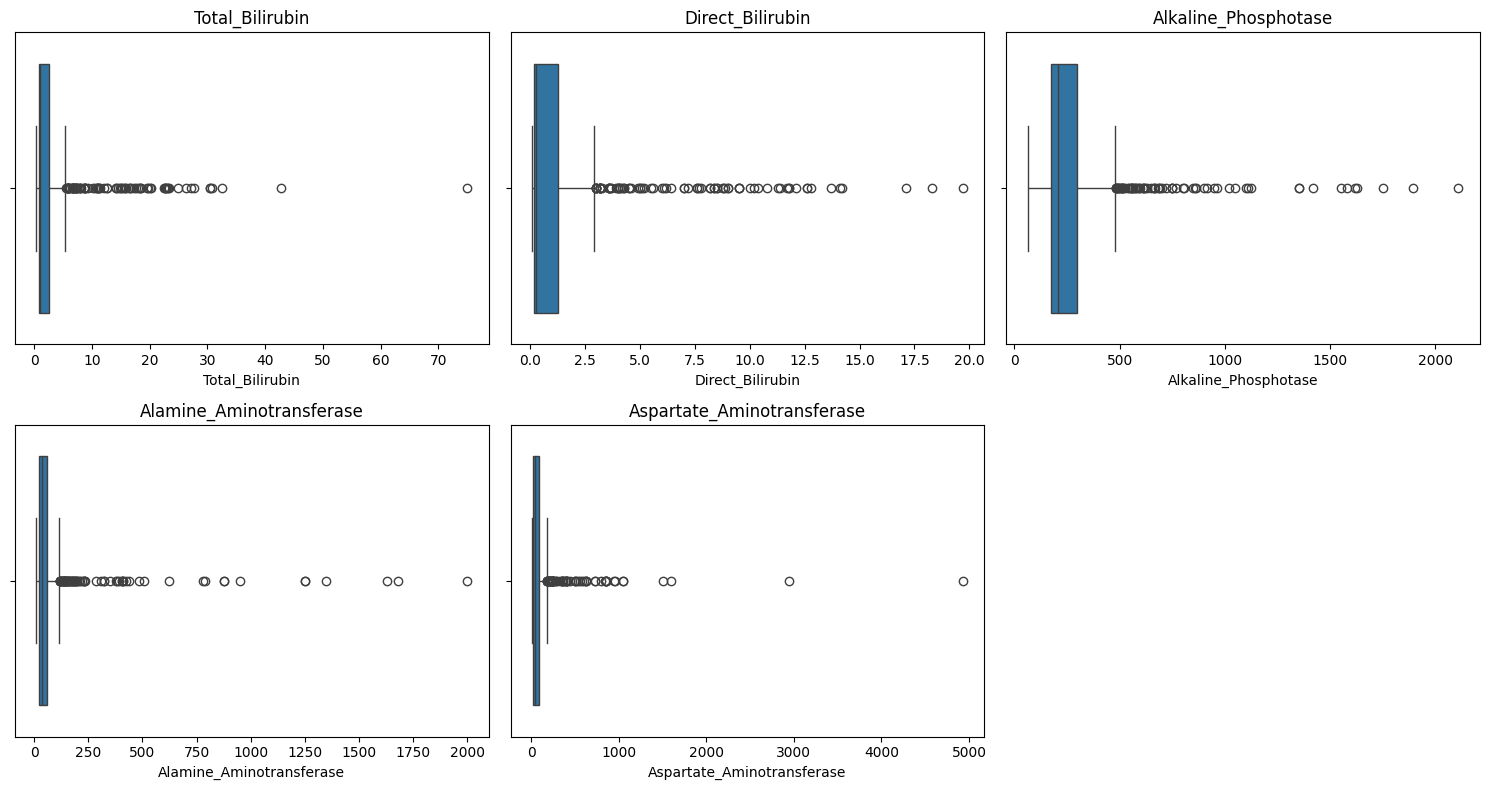

In [234]:
# Features with Outliers
outlier_cols = ["Total_Bilirubin", "Direct_Bilirubin", "Alkaline_Phosphotase", "Alamine_Aminotransferase", "Aspartate_Aminotransferase"]

plt.figure(figsize=(15, 8))
for i, col in enumerate(outlier_cols):
  plt.subplot(2, 3, i+1)
  sns.boxplot(x=df_l[col])
  plt.title(col)
plt.tight_layout()
plt.show()

In [235]:
# Correlation of Outliers with Target
for col in outlier_cols:
  print(df_l.groupby("Dataset")[col].mean())

Dataset
0    1.142515
1    4.164423
Name: Total_Bilirubin, dtype: float64
Dataset
0    0.396407
1    1.923558
Name: Direct_Bilirubin, dtype: float64
Dataset
0    219.754491
1    319.007212
Name: Alkaline_Phosphotase, dtype: float64
Dataset
0    33.652695
1    99.605769
Name: Alamine_Aminotransferase, dtype: float64
Dataset
0     40.688623
1    137.699519
Name: Aspartate_Aminotransferase, dtype: float64


All outlier having some connection with Target

In [236]:
# Using Log Transformation to compress the outlier
for col in outlier_cols:
  df_l[col+"log"] = np.log1p(df_l[col])

In [237]:
df_l.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset', 'Total_Bilirubinlog',
       'Direct_Bilirubinlog', 'Alkaline_Phosphotaselog',
       'Alamine_Aminotransferaselog', 'Aspartate_Aminotransferaselog'],
      dtype='object')

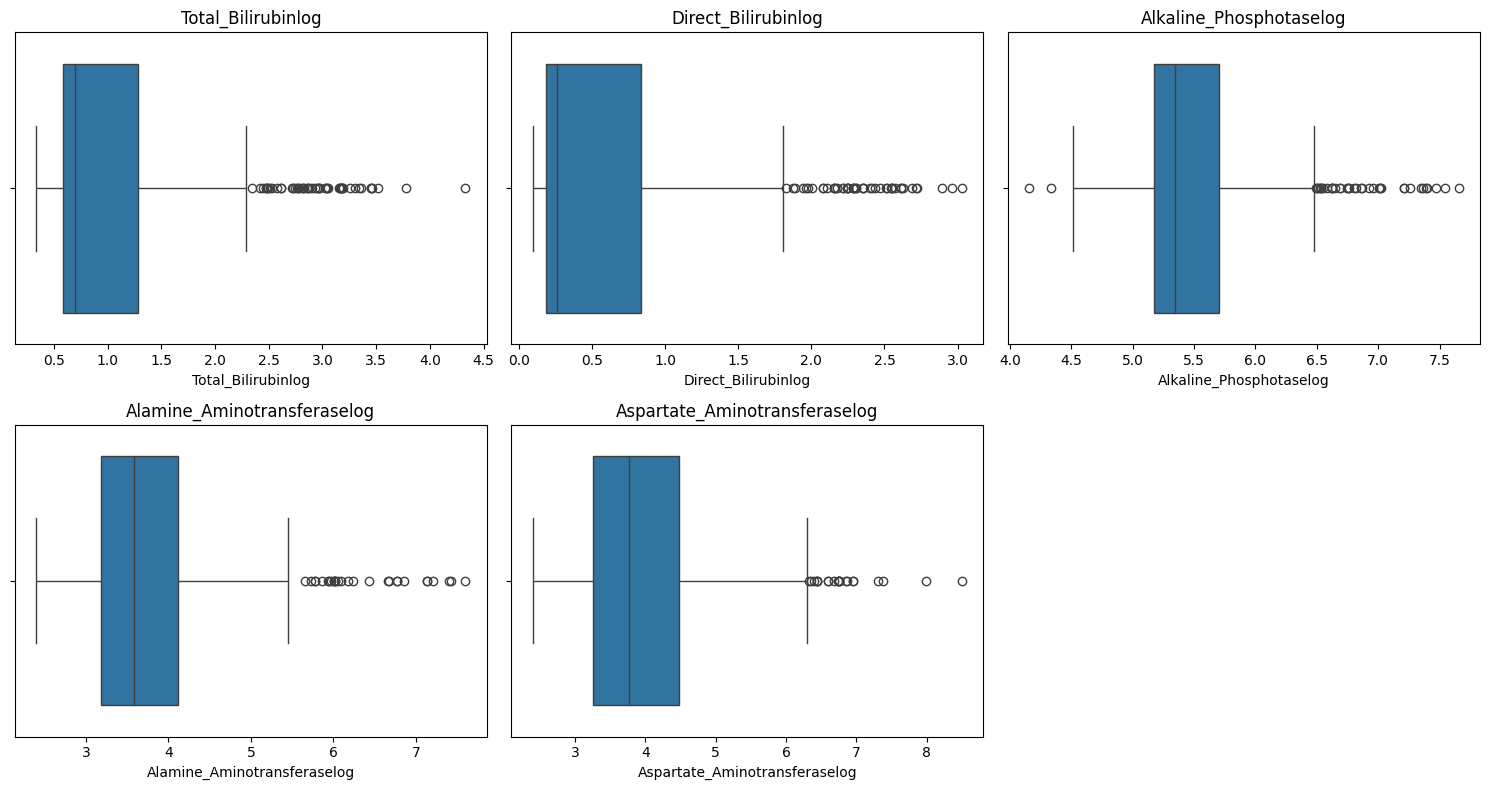

In [238]:
# Log Transformed Outliers
plt.figure(figsize=(15, 8))
for i, col in enumerate(outlier_cols):
  plt.subplot(2, 3, i+1)
  sns.boxplot(x=df_l[col+"log"])
  plt.title(col+"log")
plt.tight_layout()
plt.show()

In [239]:
# Checking skewdness on outlier
for col in outlier_cols:
  print(f"{col}: Before: {df_l[col].skew():.2f}, After: {df_l[col+"log"].skew():.2f}")

Total_Bilirubin: Before: 4.91, After: 1.73
Direct_Bilirubin: Before: 3.21, After: 1.69
Alkaline_Phosphotase: Before: 3.77, After: 1.33
Alamine_Aminotransferase: Before: 6.55, After: 1.47
Aspartate_Aminotransferase: Before: 10.55, After: 1.23


In [240]:
# Dropping old outlier columns
df_l = df_l.drop(columns=outlier_cols)

In [241]:
df_l.columns

Index(['Age', 'Gender', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset', 'Total_Bilirubinlog',
       'Direct_Bilirubinlog', 'Alkaline_Phosphotaselog',
       'Alamine_Aminotransferaselog', 'Aspartate_Aminotransferaselog'],
      dtype='object')

In [242]:
df_l.shape

(583, 11)

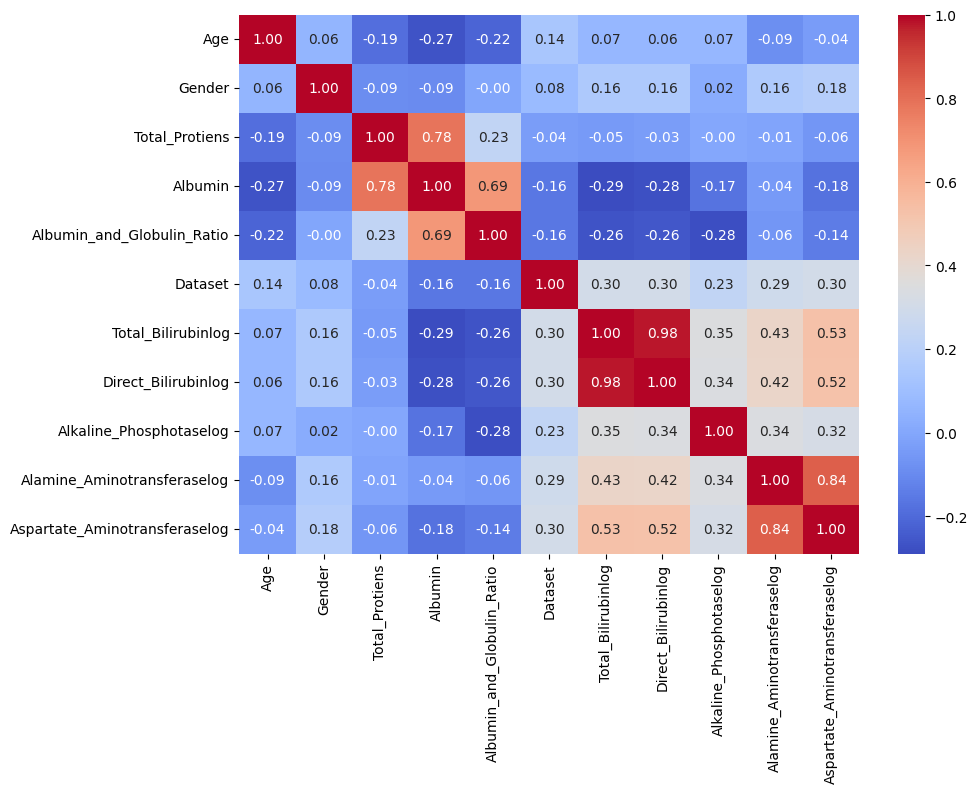

In [243]:
# Visualize correlation
plt.figure(figsize=(10, 7))
sns.heatmap(df_l.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

Direct_Bilirubinlog having high correlation with Total_Bilirubinlog

In [244]:
# Dropping Direct_Bilirubinlog
df_l = df_l.drop(columns=["Direct_Bilirubinlog"])

In [245]:
df_l.shape

(583, 10)

In [246]:
df_l.columns

Index(['Age', 'Gender', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Dataset', 'Total_Bilirubinlog',
       'Alkaline_Phosphotaselog', 'Alamine_Aminotransferaselog',
       'Aspartate_Aminotransferaselog'],
      dtype='object')

In [247]:
# Feature and Target
X_l = df_l.drop(columns=["Dataset"])
y_l = df_l["Dataset"]

In [248]:
# Train Test Split
X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_l, y_l, test_size=0.2, random_state=42, stratify=y_l)

In [249]:
# Standard Scaler
scaler_l = StandardScaler()
X_train_scaled_l = scaler_l.fit_transform(X_train_l)
X_test_scaled_l = scaler_l.transform(X_test_l)

In [250]:
# Model Training
# Logistic Regression
lr_l = LogisticRegression(class_weight="balanced", random_state=42)
lr_l.fit(X_train_scaled_l, y_train_l)
lr_pred_l = lr_l.predict(X_test_scaled_l)

In [251]:
# Evaluating Logistic Regression
evaluate("Logistic Regression", y_test_l, lr_pred_l)

Logistic Regression Evaluation:
Accuracy Score: 73.50%
Precision Score: 90.62%
Recall Score: 69.88%
F1 Score: 78.91%


In [252]:
# Evaluating with Classification report, confusion_matrix, roc_auc_score
from sklearn.metrics import classification_report
print("Logistic Regression Classification Report")
print(classification_report(y_test_l, lr_pred_l))

Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.53      0.82      0.64        34
           1       0.91      0.70      0.79        83

    accuracy                           0.74       117
   macro avg       0.72      0.76      0.72       117
weighted avg       0.80      0.74      0.75       117



In [253]:
# Adjusted threshold for Logistic Regression to improve training
lr_prob_l = lr_l.predict_proba(X_test_scaled_l)[:,1]

for i in [0.3, 0.35, 0.4, 0.45, 0.5]:
  lr_pred_adj_l = (lr_prob_l >= i).astype(int)
  print(f"Threshold: {i}")
  print(classification_report(y_test_l, lr_pred_adj_l))

Threshold: 0.3
              precision    recall  f1-score   support

           0       0.75      0.26      0.39        34
           1       0.76      0.96      0.85        83

    accuracy                           0.76       117
   macro avg       0.76      0.61      0.62       117
weighted avg       0.76      0.76      0.72       117

Threshold: 0.35
              precision    recall  f1-score   support

           0       0.67      0.47      0.55        34
           1       0.81      0.90      0.85        83

    accuracy                           0.78       117
   macro avg       0.74      0.69      0.70       117
weighted avg       0.77      0.78      0.76       117

Threshold: 0.4
              precision    recall  f1-score   support

           0       0.59      0.68      0.63        34
           1       0.86      0.81      0.83        83

    accuracy                           0.77       117
   macro avg       0.72      0.74      0.73       117
weighted avg       0.78     

Threshold: 0.45 having highest F1 Score and accuracy

In [254]:
# Using 0.45 as Threshold
threshold = 0.45
lr_pred_final_l = (lr_prob_l >= threshold).astype(int)
print(classification_report(y_test_l, lr_pred_final_l))

              precision    recall  f1-score   support

           0       0.61      0.79      0.69        34
           1       0.90      0.80      0.85        83

    accuracy                           0.79       117
   macro avg       0.76      0.79      0.77       117
weighted avg       0.82      0.79      0.80       117



In [255]:
# Random Forest Classifier
rf_l = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_l.fit(X_train_scaled_l, y_train_l)
rf_pred_l = rf_l.predict(X_test_scaled_l)

In [256]:
# Evaluating Random Forest
evaluate("Random Forest", y_test_l, rf_pred_l)

Random Forest Evaluation:
Accuracy Score: 70.94%
Precision Score: 74.26%
Recall Score: 90.36%
F1 Score: 81.52%


In [257]:
# XGBoost
# Balancing wegiths for XGBoost
xg_weights_l = (y_train_l == 0).sum() / (y_train_l == 1).sum()

xg_l = XGBClassifier(eval_metric="logloss", scale_pos_weight=xg_weights_l, random_state=42)
xg_l.fit(X_train_scaled_l, y_train_l)
xg_pred_l = xg_l.predict(X_test_scaled_l)

In [258]:
# Evaluating XGBoost
evaluate("XGBoost", y_test_l, xg_pred_l)

XGBoost Evaluation:
Accuracy Score: 71.79%
Precision Score: 76.60%
Recall Score: 86.75%
F1 Score: 81.36%


In [259]:
# Confusion matrix on models
print("Logistic Regression: \n", confusion_matrix(y_test_l, lr_pred_l))
print("Random Forest: \n", confusion_matrix(y_test_l, rf_pred_l))
print("XGBoost: \n", confusion_matrix(y_test_l, xg_pred_l))

Logistic Regression: 
 [[28  6]
 [25 58]]
Random Forest: 
 [[ 8 26]
 [ 8 75]]
XGBoost: 
 [[12 22]
 [11 72]]


In [260]:
# Tuning Threshold for Randomforest and XGBoost
# Get probabilities for class 1 from RF and XGBoost
rf_prob_l = rf_l.predict_proba(X_test_scaled_l)[:,1]
xg_prob_l = xg_l.predict_proba(X_test_scaled_l)[:,1]

for threshold in [0.5, 0.55, 0.6, 0.65, 0.7]:
    print(f"Threshold: {threshold}")

    rf_pred_adj = (rf_prob_l >= threshold).astype(int)
    print("Random Forest:")
    print(classification_report(y_test_l, rf_pred_adj))

    xg_pred_adj = (xg_prob_l >= threshold).astype(int)
    print("XGBoost:")
    print(classification_report(y_test_l, xg_pred_adj))

Threshold: 0.5
Random Forest:
              precision    recall  f1-score   support

           0       0.57      0.24      0.33        34
           1       0.75      0.93      0.83        83

    accuracy                           0.73       117
   macro avg       0.66      0.58      0.58       117
weighted avg       0.70      0.73      0.68       117

XGBoost:
              precision    recall  f1-score   support

           0       0.52      0.35      0.42        34
           1       0.77      0.87      0.81        83

    accuracy                           0.72       117
   macro avg       0.64      0.61      0.62       117
weighted avg       0.69      0.72      0.70       117

Threshold: 0.55
Random Forest:
              precision    recall  f1-score   support

           0       0.53      0.29      0.38        34
           1       0.76      0.89      0.82        83

    accuracy                           0.72       117
   macro avg       0.64      0.59      0.60       117
weig

In [261]:
# Cross Validation
lr_score_l = cross_val_score(lr_l, X_l, y_l, cv=5, scoring="f1")
print("Logistic Regression")
print(f"F1 Mean: {lr_score_l.mean():.2f}")
print(f"Standard Deviation: {lr_score_l.std():.2f}")

Logistic Regression
F1 Mean: 0.70
Standard Deviation: 0.10


## Kidney Disease Dataset

In [262]:
# Load Kidney Disease Dataset
df_k = pd.read_csv("/content/drive/MyDrive/Guvi/Project/multiple_disease_prediction/kidney_disease.csv")

In [263]:
df_k.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [264]:
df_k.shape

(400, 26)

In [265]:
df_k.columns

Index(['id', 'age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr',
       'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')

Model Details Link: [Chronic Kidney Disease](https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease)

**Columns:**
1. Age(numerical) - age in years
2. Blood Pressure(numerical) - bp in mm/Hg
3. Specific Gravity(nominal) - sg - (1.005,1.010,1.015,1.020,1.025)
4. Albumin(nominal) - al - (0,1,2,3,4,5)
5. Sugar(nominal) - su - (0,1,2,3,4,5)
6. Red Blood Cells(nominal) - rbc - (normal,abnormal)
7. Pus Cell (nominal) - pc - (normal,abnormal)
8. Pus Cell clumps(nominal) - pcc - (present,notpresent)
9. Bacteria(nominal) - ba  - (present,notpresent)
10. Blood Glucose Random(numerical) - bgr in mgs/dl
11. Blood Urea(numerical) - bu in mgs/dl
12. Serum Creatinine(numerical) - sc in mgs/dl
13. Sodium(numerical) - sod in mEq/L
14. Potassium(numerical) - pot in mEq/L
15. Hemoglobin(numerical) - hemo in gms
16. Packed  Cell Volume(numerical)
17. White Blood Cell Count(numerical) - wc in cells/cumm
18. Red Blood Cell Count(numerical) - rc in millions/cmm
19. Hypertension(nominal) - htn - (yes,no)
20. Diabetes Mellitus(nominal) - dm - (yes,no)
21. Coronary Artery Disease(nominal) - cad - (yes,no)
22. Appetite(nominal) - appet - (good,poor)
23. Pedal Edema(nominal) - pe - (yes,no)
24. Anemia(nominal) - ane - (yes,no)
25. Class (nominal) - class - (ckd,notckd)

Additionally, id shows index (not needed, as it is same as DataFrame index)

In [266]:
# Dropping id columns
df_k = df_k.drop(columns=["id"])

In [267]:
df_k.shape

(400, 25)

In [268]:
df_k.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             330 non-null    object 
 16  wc              295 non-null    object 
 17  rc              270 non-null    obj

In [269]:
df_k.describe()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [270]:
df_k.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [271]:
# number of numerical columns
print(df_k.select_dtypes(include=["float64"]).shape[1])
# number of categorical columns
print(df_k.select_dtypes(include=["object"]).shape[1])

11
14


In [272]:
print(df_k.select_dtypes(include=["float64"]).columns)
print(df_k.select_dtypes(include=["object"]).columns)

Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo'], dtype='object')
Index(['rbc', 'pc', 'pcc', 'ba', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad',
       'appet', 'pe', 'ane', 'classification'],
      dtype='object')


pcv, wc, rc are numerical as per description

In [273]:
df_k["pcv"].unique()

array(['44', '38', '31', '32', '35', '39', '36', '33', '29', '28', nan,
       '16', '24', '37', '30', '34', '40', '45', '27', '48', '?', '52',
       '14', '22', '18', '42', '17', '46', '23', '19', '25', '41', '26',
       '15', '21', '43', '20', '47', '9', '49', '50', '53', '51', '54'],
      dtype=object)

In [274]:
df_k["wc"].unique()

array(['7800', '6000', '7500', '6700', '7300', nan, '6900', '9600',
       '12100', '4500', '12200', '11000', '3800', '11400', '5300', '9200',
       '6200', '8300', '8400', '10300', '9800', '9100', '7900', '6400',
       '8600', '18900', '21600', '4300', '8500', '11300', '7200', '7700',
       '14600', '6300', '7100', '11800', '9400', '5500', '5800', '13200',
       '12500', '5600', '7000', '11900', '10400', '10700', '12700',
       '6800', '6500', '13600', '10200', '9000', '14900', '8200', '15200',
       '5000', '16300', '12400', '10500', '4200', '4700', '10900', '8100',
       '9500', '2200', '12800', '11200', '19100', '?', '12300', '16700',
       '2600', '26400', '8800', '7400', '4900', '8000', '12000', '15700',
       '4100', '5700', '11500', '5400', '10800', '9900', '5200', '5900',
       '9300', '9700', '5100', '6600'], dtype=object)

In [275]:
df_k["rc"].unique()

array(['5.2', nan, '3.9', '4.6', '4.4', '5', '4', '3.7', '3.8', '3.4',
       '2.6', '2.8', '4.3', '3.2', '3.6', '4.1', '4.9', '2.5', '4.2',
       '4.5', '3.1', '4.7', '3.5', '6', '2.1', '5.6', '2.3', '2.9', '2.7',
       '8', '3.3', '3', '2.4', '4.8', '?', '5.4', '6.1', '6.2', '6.3',
       '5.1', '5.8', '5.5', '5.3', '6.4', '5.7', '5.9', '6.5'],
      dtype=object)

In [276]:
df_k[["pcv", "wc", "rc"]].isnull().sum()

,0
pcv,70
wc,105
rc,130


In [277]:
# converting ? in pcv, wc, rc to null value
df_k["pcv"] = pd.to_numeric(df_k["pcv"], errors="coerce")
df_k["wc"] = pd.to_numeric(df_k["wc"], errors="coerce")
df_k["rc"] = pd.to_numeric(df_k["rc"], errors="coerce")

In [278]:
df_k["pcv"].unique()

array([44., 38., 31., 32., 35., 39., 36., 33., 29., 28., nan, 16., 24.,
       37., 30., 34., 40., 45., 27., 48., 52., 14., 22., 18., 42., 17.,
       46., 23., 19., 25., 41., 26., 15., 21., 43., 20., 47.,  9., 49.,
       50., 53., 51., 54.])

In [279]:
df_k.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             391 non-null    float64
 1   bp              388 non-null    float64
 2   sg              353 non-null    float64
 3   al              354 non-null    float64
 4   su              351 non-null    float64
 5   rbc             248 non-null    object 
 6   pc              335 non-null    object 
 7   pcc             396 non-null    object 
 8   ba              396 non-null    object 
 9   bgr             356 non-null    float64
 10  bu              381 non-null    float64
 11  sc              383 non-null    float64
 12  sod             313 non-null    float64
 13  pot             312 non-null    float64
 14  hemo            348 non-null    float64
 15  pcv             329 non-null    float64
 16  wc              294 non-null    float64
 17  rc              269 non-null    flo

In [280]:
# number of numerical columns
print(df_k.select_dtypes(include=["float64"]).shape[1])
# number of categorical columns
print(df_k.select_dtypes(include=["object"]).shape[1])

14
11


In [281]:
print(df_k.select_dtypes(include=["float64"]).columns)
print(df_k.select_dtypes(include=["object"]).columns)

Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo',
       'pcv', 'wc', 'rc'],
      dtype='object')
Index(['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane',
       'classification'],
      dtype='object')


In [282]:
# null values
df_k.isnull().sum().sort_values(ascending=False)

,0
rbc,152
rc,131
wc,106
pot,88
sod,87
pcv,71
pc,65
hemo,52
su,49
sg,47


In [283]:
num_cols = df_k.select_dtypes(include=["float64"]).columns
cat_cols = df_k.select_dtypes(include=["object"]).columns.drop("classification") # Except Target

In [284]:
for i in num_cols:
  print(f"Column: {i}")
  print(f"Mean: {df_k[i].mean():.2f}")
  print(f"Median: {df_k[i].median():.2f}")
  print(f"Skew: {df_k[i].skew():.2f}")
  print()

Column: age
Mean: 51.48
Median: 55.00
Skew: -0.67

Column: bp
Mean: 76.47
Median: 80.00
Skew: 1.61

Column: sg
Mean: 1.02
Median: 1.02
Skew: -0.17

Column: al
Mean: 1.02
Median: 0.00
Skew: 1.00

Column: su
Mean: 0.45
Median: 0.00
Skew: 2.46

Column: bgr
Mean: 148.04
Median: 121.00
Skew: 2.01

Column: bu
Mean: 57.43
Median: 42.00
Skew: 2.63

Column: sc
Mean: 3.07
Median: 1.30
Skew: 7.51

Column: sod
Mean: 137.53
Median: 138.00
Skew: -7.00

Column: pot
Mean: 4.63
Median: 4.40
Skew: 11.58

Column: hemo
Mean: 12.53
Median: 12.65
Skew: -0.34

Column: pcv
Mean: 38.88
Median: 40.00
Skew: -0.43

Column: wc
Mean: 8406.12
Median: 8000.00
Skew: 1.62

Column: rc
Mean: 4.71
Median: 4.80
Skew: -0.18



In [285]:
# Using median to fill null values in num_cols
for i in num_cols:
  df_k[i] = df_k[i].fillna(df_k[i].median())

In [286]:
df_k.isnull().sum().sort_values(ascending=False)

,0
rbc,152
pc,65
ba,4
pcc,4
dm,2
cad,2
htn,2
appet,1
pe,1
ane,1


In [287]:
# cat_cols
for i in cat_cols:
  print(f"{i}: {df_k[i].mode()[0]}")
  print()

rbc: normal

pc: normal

pcc: notpresent

ba: notpresent

htn: no

dm: no

cad: no

appet: good

pe: no

ane: no



In [288]:
# filling cat_cols with mode data
for i in cat_cols:
  df_k[i] = df_k[i].fillna(df_k[i].mode()[0])

In [289]:
df_k.isnull().sum().sum()

np.int64(0)

In [290]:
# values of cat_cols
for i in cat_cols:
  print(i, df_k[i].unique())

rbc ['normal' 'abnormal']
pc ['normal' 'abnormal']
pcc ['notpresent' 'present']
ba ['notpresent' 'present']
htn ['yes' 'no']
dm ['yes' 'no']
cad ['no' 'yes']
appet ['good' 'poor']
pe ['no' 'yes']
ane ['no' 'yes']


In [291]:
# Encoding cat_cols
values = {
    "normal": 1, "abnormal": 0,
    "present": 1, "notpresent": 0,
    "yes": 1, "no": 0,
    "good": 1, "poor": 0
}

for i in cat_cols:
  df_k[i] = df_k[i].map(values)

In [292]:
df_k.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,1,0,0,ckd
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,1,0,0,ckd
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,0,0,1,ckd
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,0,1,1,ckd
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,1,0,0,ckd


In [293]:
# Encoding target
df_k["classification"].unique()

array(['ckd', 'notckd'], dtype=object)

In [294]:
df_k["classification"].value_counts()

,count
classification,
ckd,250
notckd,150


In [295]:
df_k["classification"] = df_k["classification"].map({
    "ckd": 1,
    "notckd": 0
})

In [296]:
df_k.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,1,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,1,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,0,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,0,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,1,0,0,1


In [297]:
df_k["classification"].value_counts()

,count
classification,
1,250
0,150


In [298]:
df_k.isnull().sum().sum()

np.int64(0)

In [299]:
df_k.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,44.0,7800.0,5.2,1,1,0,1,0,0,1
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,38.0,6000.0,4.8,0,0,0,1,0,0,1
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,31.0,7500.0,4.8,0,1,0,0,0,1,1
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,32.0,6700.0,3.9,1,0,0,0,1,1,1
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,35.0,7300.0,4.6,0,0,0,1,0,0,1


In [300]:
df_k.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             400 non-null    float64
 1   bp              400 non-null    float64
 2   sg              400 non-null    float64
 3   al              400 non-null    float64
 4   su              400 non-null    float64
 5   rbc             400 non-null    int64  
 6   pc              400 non-null    int64  
 7   pcc             400 non-null    int64  
 8   ba              400 non-null    int64  
 9   bgr             400 non-null    float64
 10  bu              400 non-null    float64
 11  sc              400 non-null    float64
 12  sod             400 non-null    float64
 13  pot             400 non-null    float64
 14  hemo            400 non-null    float64
 15  pcv             400 non-null    float64
 16  wc              400 non-null    float64
 17  rc              400 non-null    flo

In [301]:
df_k.shape

(400, 25)

In [302]:
# Target
df_k["classification"].value_counts(normalize=True)*100

,proportion
classification,
1,62.5
0,37.5


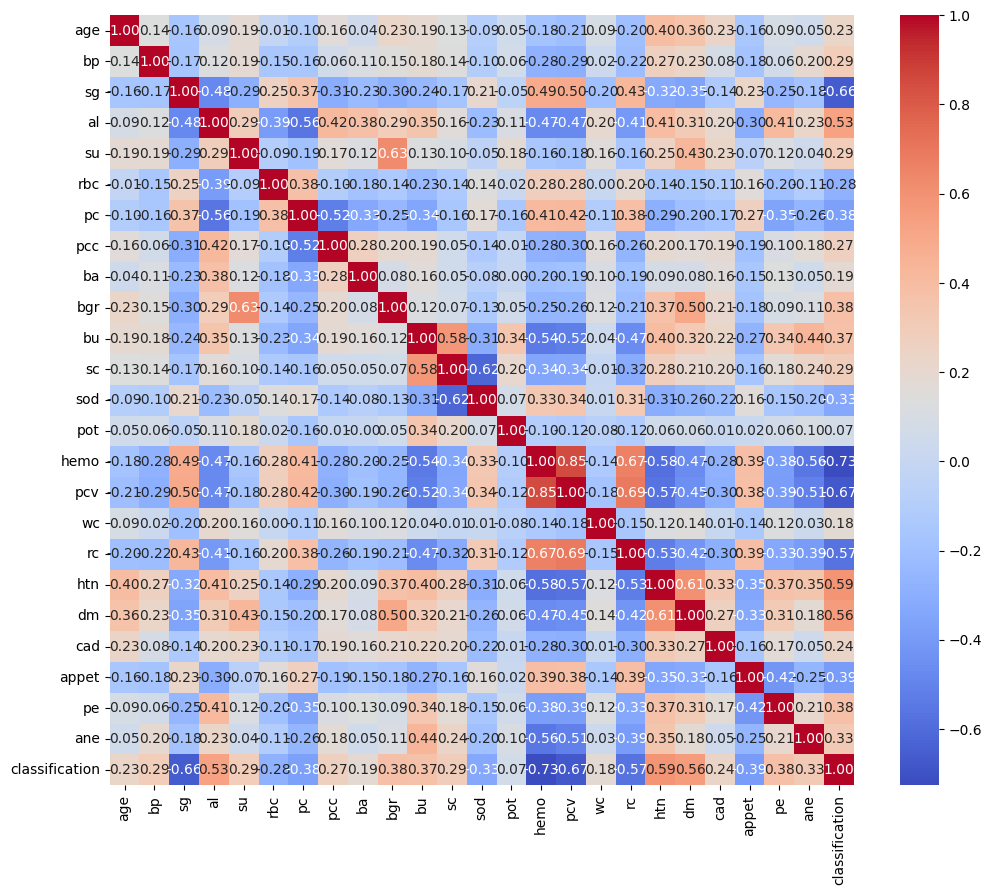

In [303]:
# Correlation
plt.figure(figsize=(12, 10))
sns.heatmap(df_k.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

hemo and pcv having highest correlation but hemo's correlation with classification is higher than pcv. So dropping pcv column

In [304]:
df_k = df_k.drop(columns=["pcv"])

In [305]:
df_k.shape

(400, 24)

In [306]:
# outlier check on num_cols
num_cols

Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo',
       'pcv', 'wc', 'rc'],
      dtype='object')

In [307]:
num_cols = num_cols.drop("pcv")

In [308]:
num_cols

Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo',
       'wc', 'rc'],
      dtype='object')

In [309]:
len(num_cols)

13

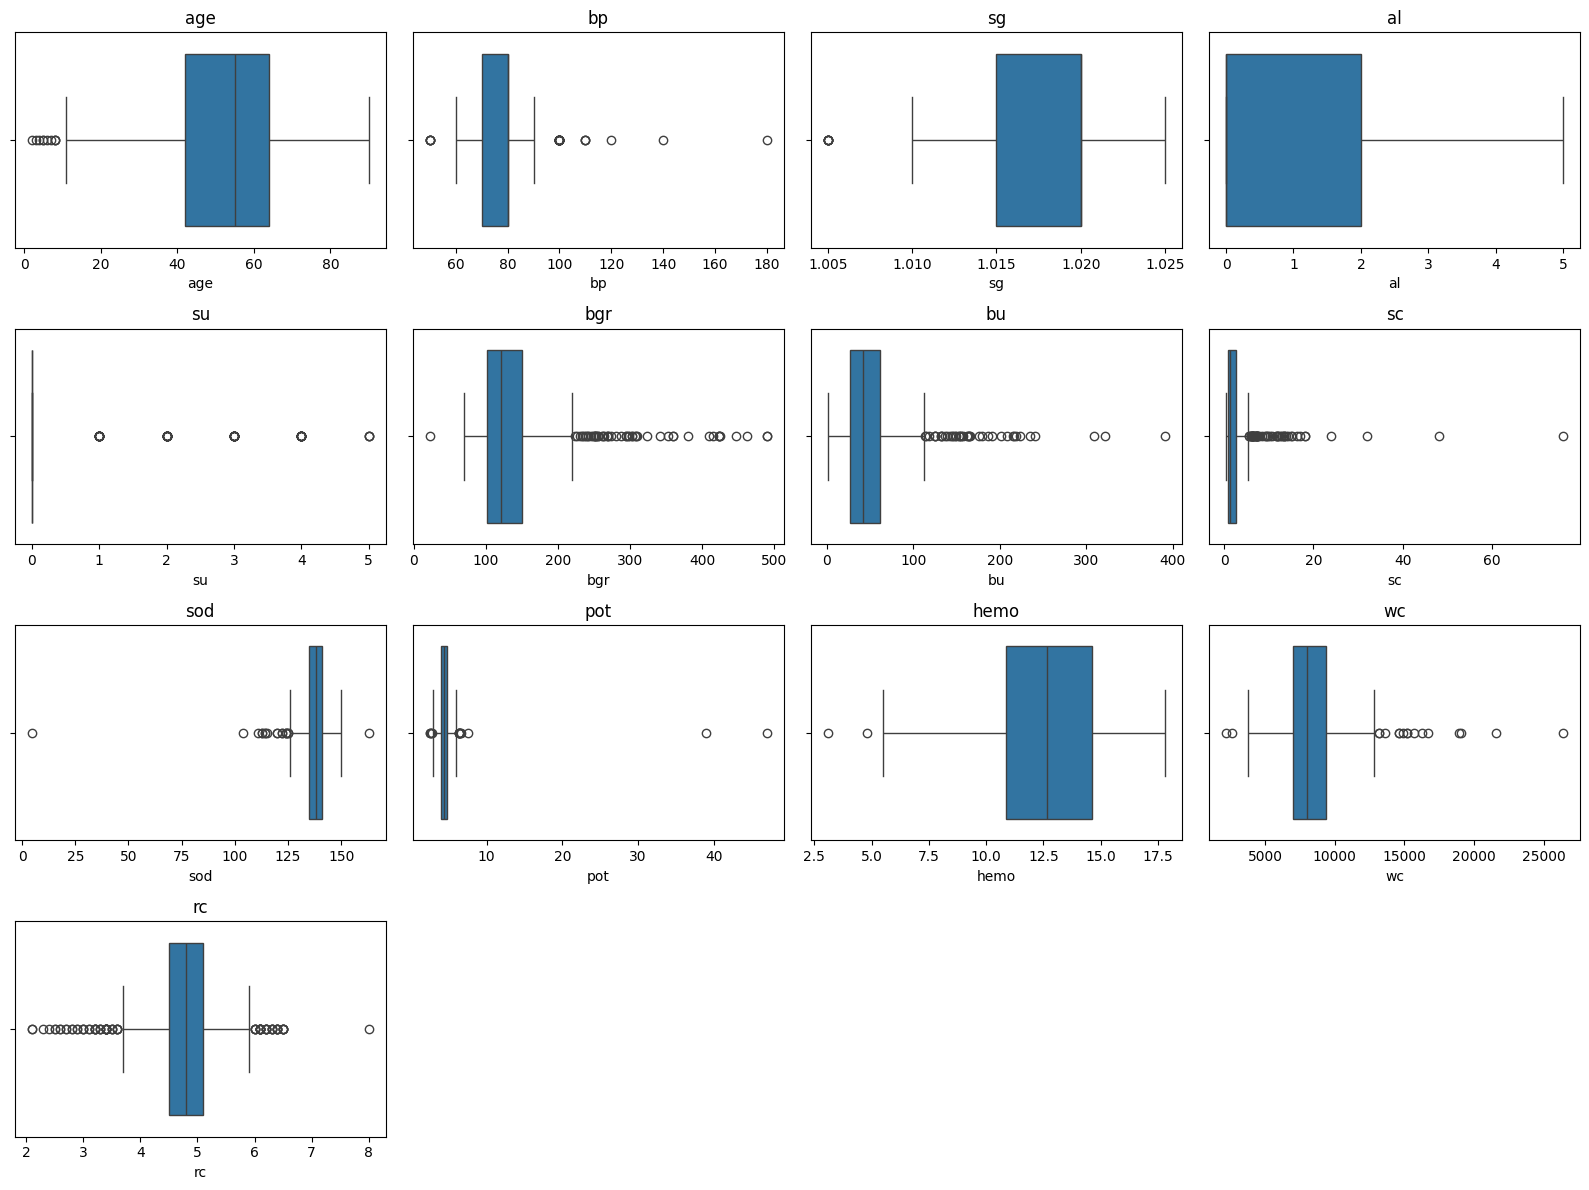

In [310]:
# visualize outlier
plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(x=df_k[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [311]:
df_k[num_cols].skew().sort_values(ascending=False)

,0
pot,13.132548
sc,7.665610
bu,2.724138
su,2.700055
bgr,2.204143
wc,2.001895
bp,1.601858
al,1.180088
rc,-0.330485
sg,-0.333320


Highly skewed outliers: pot, sc, bu, bgr, wc, bp

In [312]:
# Log Transform highly skewed outliers
highly_skewed_outliers = ["pot", "sc", "bu", "bgr", "wc", "bp"]

for i in highly_skewed_outliers:
  df_k[i+"_log"] = np.log1p(df_k[i])

In [313]:
df_k.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,appet,pe,ane,classification,pot_log,sc_log,bu_log,bgr_log,wc_log,bp_log
0,48.0,80.0,1.020,1.0,0.0,1,1,0,0,121.0,...,1,0,0,1,1.686399,0.788457,3.610918,4.804021,8.962007,4.394449
1,7.0,50.0,1.020,4.0,0.0,1,1,0,0,121.0,...,1,0,0,1,1.686399,0.587787,2.944439,4.804021,8.699681,3.931826
2,62.0,80.0,1.010,2.0,3.0,1,1,0,0,423.0,...,0,0,1,1,1.686399,1.029619,3.988984,6.049733,8.922792,4.394449
3,48.0,70.0,1.005,4.0,0.0,1,0,1,0,117.0,...,0,1,1,1,1.252763,1.568616,4.043051,4.770685,8.810012,4.262680
4,51.0,80.0,1.010,2.0,0.0,1,1,0,0,106.0,...,1,0,0,1,1.686399,0.875469,3.295837,4.672829,8.895767,4.394449


In [314]:
# dropping old outlier columns
df_k = df_k.drop(columns=highly_skewed_outliers)

In [315]:
df_k.shape

(400, 24)

In [316]:
df_k.head()

,age,sg,al,su,rbc,pc,pcc,ba,sod,hemo,...,appet,pe,ane,classification,pot_log,sc_log,bu_log,bgr_log,wc_log,bp_log
0,48.0,1.020,1.0,0.0,1,1,0,0,138.0,15.4,...,1,0,0,1,1.686399,0.788457,3.610918,4.804021,8.962007,4.394449
1,7.0,1.020,4.0,0.0,1,1,0,0,138.0,11.3,...,1,0,0,1,1.686399,0.587787,2.944439,4.804021,8.699681,3.931826
2,62.0,1.010,2.0,3.0,1,1,0,0,138.0,9.6,...,0,0,1,1,1.686399,1.029619,3.988984,6.049733,8.922792,4.394449
3,48.0,1.005,4.0,0.0,1,0,1,0,111.0,11.2,...,0,1,1,1,1.252763,1.568616,4.043051,4.770685,8.810012,4.262680
4,51.0,1.010,2.0,0.0,1,1,0,0,138.0,11.6,...,1,0,0,1,1.686399,0.875469,3.295837,4.672829,8.895767,4.394449


In [317]:
highly_skewed_outliers

['pot', 'sc', 'bu', 'bgr', 'wc', 'bp']

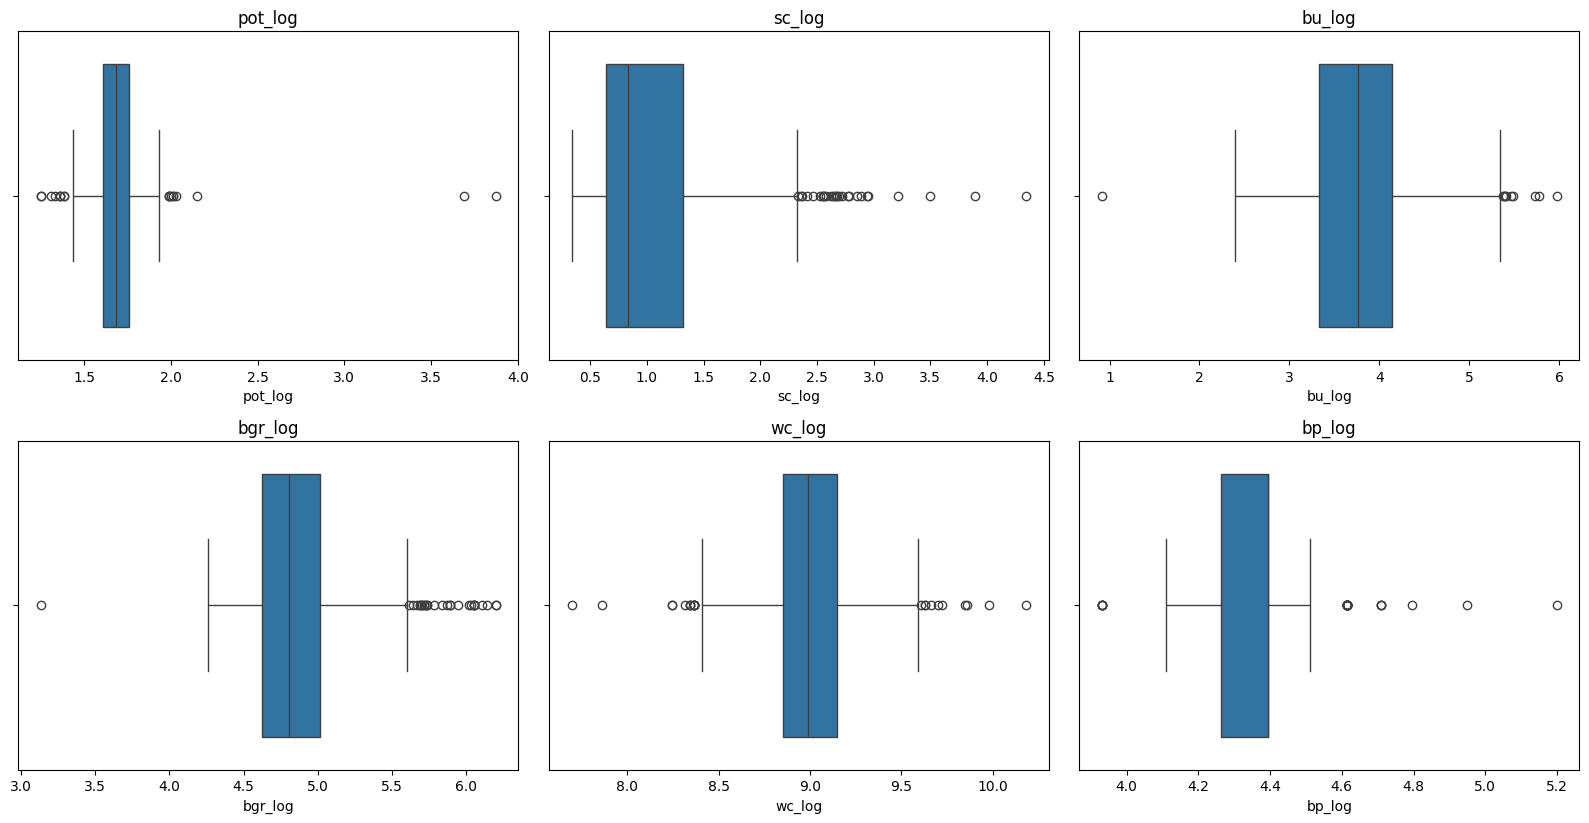

In [318]:
# visualize after log transform
plt.figure(figsize=(16, 12))
for i, col in enumerate(highly_skewed_outliers):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df_k[col+"_log"])
    plt.title(col+"_log")
plt.tight_layout()
plt.show()

In [319]:
log_cols = ["pot_log", "sc_log", "bu_log", "bgr_log", "wc_log", "bp_log"]
df_k[log_cols].skew()

,0
pot_log,6.352954
sc_log,1.679464
bu_log,0.413986
bgr_log,0.911731
wc_log,-0.126307
bp_log,0.424615


In [320]:
df_k.shape

(400, 24)

In [321]:
df_k.head()

,age,sg,al,su,rbc,pc,pcc,ba,sod,hemo,...,appet,pe,ane,classification,pot_log,sc_log,bu_log,bgr_log,wc_log,bp_log
0,48.0,1.020,1.0,0.0,1,1,0,0,138.0,15.4,...,1,0,0,1,1.686399,0.788457,3.610918,4.804021,8.962007,4.394449
1,7.0,1.020,4.0,0.0,1,1,0,0,138.0,11.3,...,1,0,0,1,1.686399,0.587787,2.944439,4.804021,8.699681,3.931826
2,62.0,1.010,2.0,3.0,1,1,0,0,138.0,9.6,...,0,0,1,1,1.686399,1.029619,3.988984,6.049733,8.922792,4.394449
3,48.0,1.005,4.0,0.0,1,0,1,0,111.0,11.2,...,0,1,1,1,1.252763,1.568616,4.043051,4.770685,8.810012,4.262680
4,51.0,1.010,2.0,0.0,1,1,0,0,138.0,11.6,...,1,0,0,1,1.686399,0.875469,3.295837,4.672829,8.895767,4.394449


In [322]:
# Feature and Target
X_k = df_k.drop(columns=["classification"])
y_k = df_k["classification"]

In [323]:
# Train Test Split
X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(X_k, y_k, test_size=0.2, random_state=42, stratify=y_k)

In [324]:
X_train_k.shape

(320, 23)

In [325]:
X_test_k.shape

(80, 23)

In [326]:
y_train_k.shape

(320,)

In [327]:
y_test_k.shape

(80,)

In [328]:
# Scaling
scaler_k = StandardScaler()

X_train_scaled_k = scaler_k.fit_transform(X_train_k)
X_test_scaled_k = scaler_k.transform(X_test_k)

In [329]:
# Model Training
# Logistic Regression
lr_k = LogisticRegression(random_state=42)
lr_k.fit(X_train_scaled_k, y_train_k)
lr_pred_k = lr_k.predict(X_test_scaled_k)

In [330]:
# Evaluating Logistic Regression
evaluate("Logistic Regression", y_test_k, lr_pred_k)

Logistic Regression Evaluation:
Accuracy Score: 100.00%
Precision Score: 100.00%
Recall Score: 100.00%
F1 Score: 100.00%


In [331]:
# Random forest
rf_k = RandomForestClassifier(random_state=42)
rf_k.fit(X_train_scaled_k, y_train_k)
rf_pred_k = rf_k.predict(X_test_scaled_k)

In [332]:
# Evaluating Random Forest
evaluate("Random forest", y_test_k, rf_pred_k)

Random forest Evaluation:
Accuracy Score: 100.00%
Precision Score: 100.00%
Recall Score: 100.00%
F1 Score: 100.00%


In [333]:
# XGBoost
xg_k = XGBClassifier(eval_metric="logloss", random_state=42)
xg_k.fit(X_train_scaled_k, y_train_k)
xg_pred_k = xg_k.predict(X_test_scaled_k)

In [334]:
# Evaluating XGBoost
evaluate("XGBoost", y_test_k, xg_pred_k)

XGBoost Evaluation:
Accuracy Score: 98.75%
Precision Score: 100.00%
Recall Score: 98.00%
F1 Score: 98.99%


In [335]:
# Confusion matrix on models
print("Logistic Regression: \n", confusion_matrix(y_test_k, lr_pred_k))
print("Random Forest: \n", confusion_matrix(y_test_k, rf_pred_k))
print("XGBoost: \n", confusion_matrix(y_test_k, xg_pred_k))

Logistic Regression: 
 [[30  0]
 [ 0 50]]
Random Forest: 
 [[30  0]
 [ 0 50]]
XGBoost: 
 [[30  0]
 [ 1 49]]


In [336]:
# Cross Validation Function
def cross_validate(model_name, model):
  score = cross_val_score(model, X_k, y_k, cv=5, scoring="f1")
  print(f"{model_name}")
  print(f"F1 Mean: {score.mean():.2f}")
  print(f"Standard Deviation: {score.std():.2f}")
  print()

In [337]:
cross_validate("Logistic Regression", lr_k)
cross_validate("Random Forest", rf_k)
cross_validate("XGBoost", xg_k)

Logistic Regression
F1 Mean: 0.98
Standard Deviation: 0.02

Random Forest
F1 Mean: 0.99
Standard Deviation: 0.01

XGBoost
F1 Mean: 0.99
Standard Deviation: 0.01



## Save Model and Scaler files

In [338]:
models = {
    "parkinsons_lr": lr_p, "parkinsons_rf": rf_p, "parkinsons_xg": xg_p,
    "liver_lr": lr_l, "liver_rf": rf_l, "liver_xg": xg_l,
    "kidney_lr": lr_k, "kidney_rf": rf_k, "kidney_xg": xg_k
}
scalers = {
    "parkinsons": scaler_p,
    "liver": scaler_l,
    "kidney": scaler_k
}

import joblib
for i, j in models.items():
  joblib.dump(j, i+"_model.pkl")
for i, j in scalers.items():
  joblib.dump(j, i+"_scaler.pkl")

In [339]:
disease = ["parkinsons", "liver", "kidney"]
models = ["lr", "rf", "xg"]
files = {}
path = "/content/"
for i in disease:
  for j in models:
    name = i+"_"+j
    files[name] = joblib.load(path+name+"_model.pkl")
  files[i+"_scaler"] = joblib.load(path+i+"_scaler.pkl")
files

{'parkinsons_lr': LogisticRegression(max_iter=1000, random_state=42),
 'parkinsons_rf': RandomForestClassifier(random_state=42),
 'parkinsons_xg': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=True, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, ...),
 'parkinsons_scaler': StandardScaler(),
 'liver_lr': LogisticR